In [1]:
#Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
#Generate Environmental Dataset

np.random.seed(42)

n = 1000

data = pd.DataFrame({
    "Temperature": np.random.uniform(15, 45, n),
    "Humidity": np.random.uniform(10, 90, n),
    "Rainfall": np.random.uniform(0, 300, n),
    "Soil_pH": np.random.uniform(4, 9, n),
    "NDVI": np.random.uniform(0.2, 0.9, n)
})

data["Fire_Risk"] = (
    (data["Temperature"] > 35) &
    (data["Humidity"] < 30) &
    (data["NDVI"] < 0.4)
).astype(int)

data["Latitude"] = np.random.uniform(8, 37, n)
data["Longitude"] = np.random.uniform(68, 97, n)

data.head()

,Temperature,Humidity,Rainfall,Soil_pH,NDVI,Fire_Risk,Latitude,Longitude
0,26.236204,24.810634,78.511705,7.363515,0.600397,0,19.415430,86.799452
1,43.521429,53.352076,74.093640,7.983407,0.763803,0,21.729634,72.999205
2,36.959818,79.835667,271.876374,5.252339,0.732113,0,32.781874,93.299442
3,32.959755,68.577991,74.863860,7.124370,0.307730,0,17.860127,85.780371
4,19.680559,74.524892,81.584918,6.858730,0.304475,0,33.219841,72.558913


In [3]:
#Feature & Target

X = data[["Temperature", "Humidity", "Rainfall", "Soil_pH", "NDVI"]]
y = data["Fire_Risk"]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
#Build Deep Learning Model (TensorFlow)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=40,
    validation_data=(X_test, y_test)
)

Epoch 1/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9600 - loss: 0.4801 - val_accuracy: 0.9750 - val_loss: 0.3871
Epoch 2/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9850 - loss: 0.2917 - val_accuracy: 0.9750 - val_loss: 0.2512
Epoch 3/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9850 - loss: 0.1844 - val_accuracy: 0.9750 - val_loss: 0.1754
Epoch 4/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9850 - loss: 0.1260 - val_accuracy: 0.9750 - val_loss: 0.1363
Epoch 5/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9850 - loss: 0.0947 - val_accuracy: 0.9750 - val_loss: 0.1163
Epoch 6/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9850 - loss: 0.0788 - val_accuracy: 0.9750 - val_loss: 0.1052
Epoch 7/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9850 - loss: 0.0695 - val_accuracy: 0.9750 - val_loss: 0.0968
Epoch 8/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9850 - loss: 0.0633 - val_accuracy: 0.9750 - val_

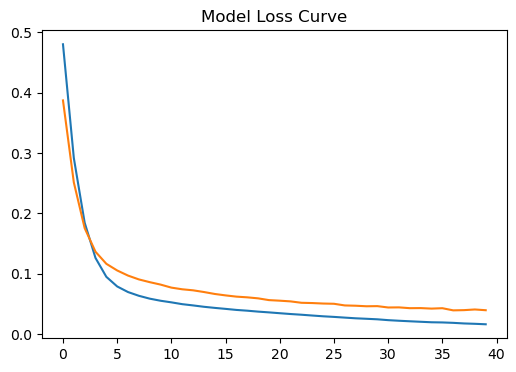

In [5]:
#Training Graph

plt.figure(figsize=(6,4))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss Curve")
plt.show()

In [6]:
#Predict Fire Probability

fire_prob = model.predict(X)
fire_prob = fire_prob.flatten()

data["Fire_Probability"] = fire_prob
data["Fire_Predicted"] = (fire_prob > 0.5).astype(int)

data.head()

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


,Temperature,Humidity,Rainfall,Soil_pH,NDVI,Fire_Risk,Latitude,Longitude,Fire_Probability,Fire_Predicted
0,26.236204,24.810634,78.511705,7.363515,0.600397,0,19.415430,86.799452,1.039280e-03,0
1,43.521429,53.352076,74.093640,7.983407,0.763803,0,21.729634,72.999205,1.426780e-05,0
2,36.959818,79.835667,271.876374,5.252339,0.732113,0,32.781874,93.299442,7.445721e-07,0
3,32.959755,68.577991,74.863860,7.124370,0.307730,0,17.860127,85.780371,1.445503e-04,0
4,19.680559,74.524892,81.584918,6.858730,0.304475,0,33.219841,72.558913,9.661757e-07,0


In [7]:
#Model Evaluation

print(confusion_matrix(y, data["Fire_Predicted"]))
print(classification_report(y, data["Fire_Predicted"]))

[[983   0]
 [  7  10]]
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       983
           1       1.00      0.59      0.74        17

    accuracy                           0.99      1000
   macro avg       1.00      0.79      0.87      1000
weighted avg       0.99      0.99      0.99      1000



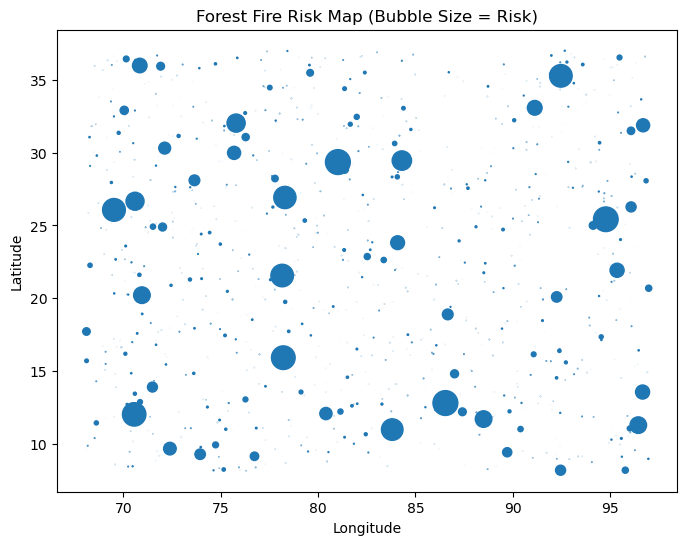

In [8]:
#Geographic Fire Risk Map

plt.figure(figsize=(8,6))

plt.scatter(
    data["Longitude"],
    data["Latitude"],
    s=data["Fire_Probability"] * 400
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Forest Fire Risk Map (Bubble Size = Risk)")
plt.show()

In [9]:
#Environmental Risk Score

data["Environmental_Risk_Score"] = (
    data["Fire_Probability"] * 0.6 +
    (1 - data["NDVI"]) * 0.4
)

In [ ]:
def generate_report(row):

    report = f"""
    🌍 Environmental AI Report
    --------------------------
    Location: ({row['Latitude']:.2f}, {row['Longitude']:.2f})

    Temperature: {row['Temperature']:.1f} °C
    Humidity: {row['Humidity']:.1f} %
    Rainfall: {row['Rainfall']:.1f} mm
    NDVI: {row['NDVI']:.2f}

    Fire Probability: {row['Fire_Probability']:.2f}
    """

    if row["Fire_Probability"] > 0.7:
        report += "\n🔥 CRITICAL FIRE ALERT!"
    elif row["Fire_Probability"] > 0.4:
        report += "\n⚠ Moderate Fire Risk"
    else:
        report += "\n✅ Low Fire Risk"

    if row["NDVI"] < 0.4:
        report += "\n🌱 Vegetation Health is Low."

    if row["Temperature"] > 38:
        report += "\n🌡 Extreme Temperature Warning."

    report += "\n\n🌿 AI Recommendation: Increase irrigation and reduce dry biomass."

    return report


print(generate_report(data.iloc[0]))